In [8]:
import math

import numpy as np
import scipy as sp
from numpy.typing import ArrayLike

import matplotlib.pyplot as plt

In [82]:
def transform_op(op: ArrayLike, trans_op: ArrayLike) -> ArrayLike:
    return np.conjugate(trans_op).T @ op @ trans_op

def get_low_op(dim: int) -> np.ndarray:
    low_op = np.diag(np.sqrt(np.arange(1, dim)), 1)
    return low_op

def get_raise_op(dim: int) -> np.ndarray:
    low_op = get_low_op(dim)
    return np.transpose(np.conjugate(low_op))

def get_charge_op(charge_cutoff: float, offset_charge: float) -> ArrayLike:
    charge_dim = 2 * charge_cutoff + 1
    charge_vals = np.arange(-charge_cutoff, charge_cutoff + 1)
    n_op = np.diag(charge_vals)
    id_op = np.identity(charge_dim)
    offset_op = n_op - offset_charge * id_op
    return offset_op


def get_cosphi_op(charge_cutoff: float) -> ArrayLike:
    offdiag_elems = np.ones(2 * charge_cutoff)
    superdiag_mat = np.diag(0.5 * offdiag_elems, 1)
    subdiag_mat = np.transpose(superdiag_mat)
    cosphi_op = superdiag_mat + subdiag_mat
    return cosphi_op


def get_sinphi_op(charge_cutoff: float) -> ArrayLike:
    offdiag_elems = np.ones(2 * charge_cutoff)
    superdiag_mat = np.diag(0.5j * offdiag_elems, 1)
    subdiag_mat = np.transpose(superdiag_mat)
    sinphi_op = superdiag_mat - subdiag_mat
    return sinphi_op


def get_kinetic_term(
    charging_energy: float,
    offset_charge: float,
    charge_cutoff: float,
) -> ArrayLike:
    charge_op = get_charge_op(charge_cutoff, offset_charge)
    kinetic_term = 4 * charging_energy * charge_op @ charge_op
    return kinetic_term


def get_potential_term(
    josephson_energy: float,
    ext_flux: float,
    asymmetry: float,
    charge_cutoff: float,
) -> float:
    cosphi_op = get_cosphi_op(charge_cutoff)
    cos_term = np.cos(ext_flux) * cosphi_op

    sinphi_op = get_sinphi_op(charge_cutoff)
    sin_term = asymmetry * np.sin(ext_flux) * sinphi_op

    potential_term = -josephson_energy * (cos_term + sin_term)
    return potential_term


def get_hamiltonian(
    charging_energy: float,
    josephson_energy: float,
    ext_flux: float,
    asymmetry: float,
    offset_charge: float,
    charge_cutoff: float,
):
    kinetic_term = get_kinetic_term(charging_energy, offset_charge, charge_cutoff)
    potential_term = get_potential_term(
        josephson_energy, ext_flux, asymmetry, charge_cutoff
    )
    hamiltonian = kinetic_term + potential_term
    return hamiltonian


def get_flux_drive_hamiltonian(
    josephson_energy: float,
    applied_flux: float,
    ext_flux: float,
    asymmetry: float,
    charge_cutoff: float,
    trans_op: ArrayLike | None = None
):
    cos_diff = np.cos(applied_flux) - np.cos(ext_flux)
    cos_prefactor = -josephson_energy * cos_diff
    cosphi_op = get_cosphi_op(charge_cutoff)
    if trans_op is not None:
        cosphi_op = transform_op(cosphi_op, trans_op)
    cos_term = cos_prefactor * cosphi_op

    sin_diff = np.sin(applied_flux) - np.sin(ext_flux)
    sin_prefactor = -josephson_energy * asymmetry * sin_diff
    sinphi_op = get_sinphi_op(charge_cutoff)
    if trans_op is not None:
        sinphi_op = transform_op(sinphi_op, trans_op)
    sin_term = sin_prefactor * sinphi_op

    return cos_term + sin_term

def get_approx_freq(
    charging_energy: float,
    josephson_energy: float,
    ext_flux: float,
    asymmetry: float,
) -> float:
    cos_term = np.cos(ext_flux)
    sqrt_term = np.sqrt(1 + asymmetry**2 * np.tan(ext_flux) ** 2)
    eff_josephson_energy = josephson_energy * np.abs(cos_term) * sqrt_term

    res_frequency = np.sqrt(8 * charging_energy * eff_josephson_energy)
    frequnecy = res_frequency - charging_energy
    return frequnecy

Define some units

In [37]:
# units
MHz, GHz = 1e-3, 1
ns, us = 1 * 2 * math.pi, 1e3 * 2 * math.pi

Define the constant parameters

In [85]:
CHARGING_ENERGY = 0.17874386390652913 * GHz
JOSEPHSON_ENERGY = 28.045385714769342 * GHz
ASYMMETRY = 0.617379794210013
CHARGE_CUTOFF = 100
OFFSET_CHARGE = 0.0
EXT_FLUX = 0.0

In [93]:
hamiltonian = get_hamiltonian(
    CHARGING_ENERGY,
    JOSEPHSON_ENERGY,
    EXT_FLUX,
    ASYMMETRY,
    OFFSET_CHARGE,
    CHARGE_CUTOFF,
)
eig_vals = sp.linalg.eigh(hamiltonian, eigvals_only=True)
norm_vals = eig_vals - eig_vals[0]

frequency = norm_vals[1] - norm_vals[0]
anharmonicity = norm_vals[2] - norm_vals[1] - frequency

In [94]:
print("Transmon frequency: ", frequency / GHz, "GHz")
print("Transmon anharmonicity: ", anharmonicity / MHz, "MHz")

Transmon frequency:  6.148527922400522 GHz
Transmon anharmonicity:  -191.81830626434504 MHz


### Scan of the instantaneous energy levels as a function of the applied flux through the SQUID of a transmon

External flux scan 

In [95]:
num_points = 201
flux_bound = 2 * math.pi
fluxes = np.linspace(-flux_bound, flux_bound, num_points)

In [97]:
charge_dim = 2 * CHARGE_CUTOFF + 1
exact_evals = np.zeros((num_points, charge_dim))
for idx, flux in enumerate(fluxes):
    hamiltonian = get_hamiltonian(
        CHARGING_ENERGY,
        JOSEPHSON_ENERGY,
        flux,
        ASYMMETRY,
        OFFSET_CHARGE,
        CHARGE_CUTOFF,
    )
    eig_vals = sp.linalg.eigh(hamiltonian, eigvals_only=True)
    norm_vals = eig_vals - eig_vals[0]
    exact_evals[idx] = norm_vals

drive_evals = np.zeros((num_points, charge_dim))
for idx, flux in enumerate(fluxes):
    hamiltonian = get_hamiltonian(
        CHARGING_ENERGY,
        JOSEPHSON_ENERGY,
        EXT_FLUX,
        ASYMMETRY,
        OFFSET_CHARGE,
        CHARGE_CUTOFF,
    )

    drive_hamiltonian = get_flux_drive_hamiltonian(
        JOSEPHSON_ENERGY,
        flux,
        EXT_FLUX,
        ASYMMETRY,
        CHARGE_CUTOFF,
    )

    full_hamiltonian = hamiltonian + drive_hamiltonian
    eig_vals = sp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_vals = eig_vals - eig_vals[0]
    drive_evals[idx] = norm_vals


In [98]:
assert np.allclose(exact_evals, drive_evals)

In [99]:
diag_drive_evals = np.zeros((num_points, charge_dim))
for idx, flux in enumerate(fluxes):
    hamiltonian = get_hamiltonian(
        CHARGING_ENERGY,
        JOSEPHSON_ENERGY,
        EXT_FLUX,
        ASYMMETRY,
        OFFSET_CHARGE,
        CHARGE_CUTOFF,
    )

    _, trans_op = sp.linalg.eigh(hamiltonian)
    diag_hamiltonian = transform_op(hamiltonian, trans_op)

    drive_hamiltonian = get_flux_drive_hamiltonian(
        JOSEPHSON_ENERGY,
        flux,
        EXT_FLUX,
        ASYMMETRY,
        CHARGE_CUTOFF,
    )
    diag_drive_hamiltonian = transform_op(drive_hamiltonian, trans_op)

    full_hamiltonian = diag_hamiltonian + diag_drive_hamiltonian
    eig_vals = sp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_vals = eig_vals - eig_vals[0]
    diag_drive_evals[idx] = norm_vals

In [100]:
np.allclose(exact_evals, diag_drive_evals)

True

In [101]:
trunc_dim = 10
trunc_drive_evals = np.zeros((num_points, trunc_dim))
for idx, flux in enumerate(fluxes):
    hamiltonian = get_hamiltonian(
        CHARGING_ENERGY,
        JOSEPHSON_ENERGY,
        EXT_FLUX,
        ASYMMETRY,
        OFFSET_CHARGE,
        CHARGE_CUTOFF,
    )

    _, trans_op = sp.linalg.eigh(hamiltonian)
    trunc_op = trans_op[:, :trunc_dim]
    diag_hamiltonian = transform_op(hamiltonian, trunc_op)

    drive_hamiltonian = get_flux_drive_hamiltonian(
        JOSEPHSON_ENERGY,
        flux,
        EXT_FLUX,
        ASYMMETRY,
        CHARGE_CUTOFF,
    )
    diag_drive_hamiltonian = transform_op(drive_hamiltonian, trunc_op)

    full_hamiltonian = diag_hamiltonian + diag_drive_hamiltonian
    eig_vals = sp.linalg.eigh(full_hamiltonian, eigvals_only=True)
    norm_vals = eig_vals - eig_vals[0]
    trunc_drive_evals[idx] = norm_vals

In [103]:
approx_evals = np.zeros((num_points, trunc_dim))
for idx, flux in enumerate(fluxes):
    for state in range(trunc_dim):
        approx_freq = get_approx_freq(
            CHARGING_ENERGY,
            JOSEPHSON_ENERGY,
            flux,
            ASYMMETRY,
        )

        raise_op = get_raise_op(trunc_dim)
        low_op = get_low_op(trunc_dim)
        harmonic_term = approx_freq * raise_op @ low_op
        anharmonic_term = 0.5 * anharmonicity * raise_op @ raise_op @ low_op @ low_op
        diag_hamiltonian = harmonic_term + anharmonic_term

        eig_vals = sp.linalg.eigh(diag_hamiltonian, eigvals_only=True)
        norm_vals = eig_vals - eig_vals[0]
        approx_evals[idx] = norm_vals

In [104]:
eval_diff = np.abs(exact_evals[:, :trunc_dim] - trunc_drive_evals)

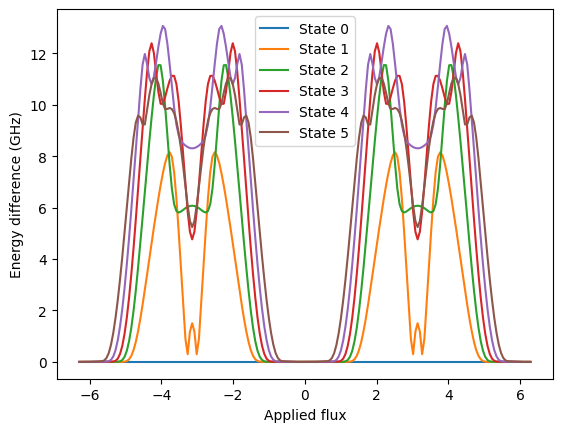

In [105]:
num_states = 6
fig, ax = plt.subplots()
for state in range(num_states):
    ax.plot(fluxes, eval_diff[:, state], label=f"State {state}")

ax.set_xlabel("Applied flux")
ax.set_ylabel("Energy difference (GHz)")
ax.legend()
plt.show()

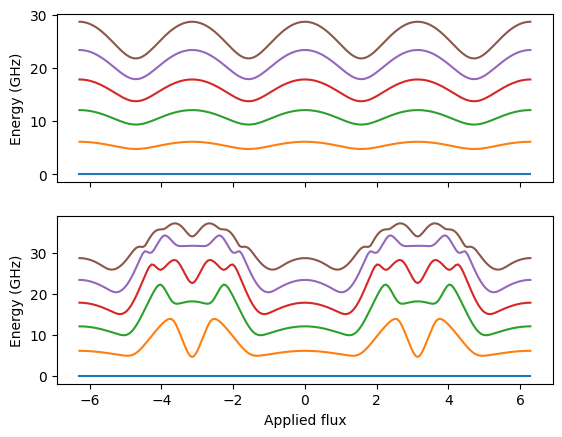

In [106]:
num_states = 6
fig, (exact_ax, trunc_ax) = plt.subplots(nrows=2, sharex=True)

for state in range(num_states):
    exact_ax.plot(fluxes, exact_evals[:, state], label=f"State {state}")

    trunc_ax.plot(fluxes, trunc_drive_evals[:, state], label=f"State {state}")

exact_ax.set_ylabel("Energy (GHz)")
trunc_ax.set_ylabel("Energy (GHz)")
trunc_ax.set_xlabel("Applied flux")
ax.legend()
plt.show()

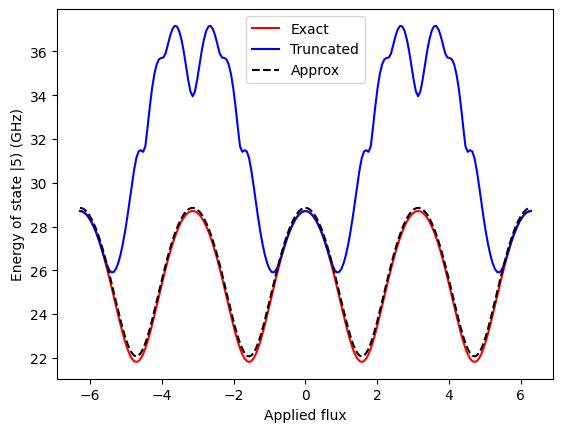

In [112]:
level = 5

fig, ax = plt.subplots()

ax.plot(fluxes, exact_evals[:, level], label="Exact", color="red")
ax.plot(fluxes, trunc_drive_evals[:, level], label="Truncated", color="blue")
ax.plot(fluxes, approx_evals[:, level], label="Approx", linestyle="--", color="black")

ax.set_xlabel("Applied flux")
ax.set_ylabel(f"Energy of state |{state}) (GHz)")
ax.legend()
plt.show()